In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix 

In [2]:
df = pd.read_excel('glass.xlsx',sheet_name=1)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
df.shape

(214, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278
Type,-0.164237,0.502898,-0.744993,0.598829,0.151565,-0.010054,0.000952,0.575161,-0.188278,1.000000


In [7]:
stats = pd.DataFrame({
    'Mean' : df.mean(),
    'Median' : df.median(),
    'Mode' : df.mode().iloc[0],
    'Min' : df.min(),
    'Max' : df.max(),
    'Q1' : df.quantile(0.25),
    'Q2' : df.quantile(0.50),
    'Q3' : df.quantile(0.75),
    'IQR' : df.quantile(0.75) - df.quantile(0.25),
    'Missing Values' : df.isnull().sum()
})
stats

,Mean,Median,Mode,Min,Max,Q1,Q2,Q3,IQR,Missing Values
RI,1.518365,1.51768,1.5159,1.51115,1.53393,1.516522,1.51768,1.519157,0.002635,0
Na,13.407850,13.30000,13.0000,10.73000,17.38000,12.907500,13.30000,13.825000,0.917500,0
Mg,2.684533,3.48000,0.0000,0.00000,4.49000,2.115000,3.48000,3.600000,1.485000,0
Al,1.444907,1.36000,1.5400,0.29000,3.50000,1.190000,1.36000,1.630000,0.440000,0
Si,72.650935,72.79000,72.8600,69.81000,75.41000,72.280000,72.79000,73.087500,0.807500,0
K,0.497056,0.55500,0.0000,0.00000,6.21000,0.122500,0.55500,0.610000,0.487500,0
Ca,8.956963,8.60000,8.0300,5.43000,16.19000,8.240000,8.60000,9.172500,0.932500,0
Ba,0.175047,0.00000,0.0000,0.00000,3.15000,0.000000,0.00000,0.000000,0.000000,0
Fe,0.057009,0.00000,0.0000,0.00000,0.51000,0.000000,0.00000,0.100000,0.100000,0
Type,2.780374,2.00000,2.0000,1.00000,7.00000,1.000000,2.00000,3.000000,2.000000,0


The statistical summary gives us a quick understanding of the central value and spread of each feature. The mean represents the average value, while the median represents the middle value. The minimum and maximum show the overall range. Q1 and Q3 represent the middle 50% of the data, and the IQR shows how spread out that middle portion is. There are no missing values in any of the features.

In [8]:
print("Duplicates: ",df.duplicated().sum())

Duplicates:  1


In [9]:
import warnings
warnings.filterwarnings('ignore')
df = df.drop_duplicates()
print("Shape after removing a Duplicate", df.shape)

Shape after removing a Duplicate (213, 10)


In [10]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [11]:
print(df['Type'].value_counts().sort_index())

Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


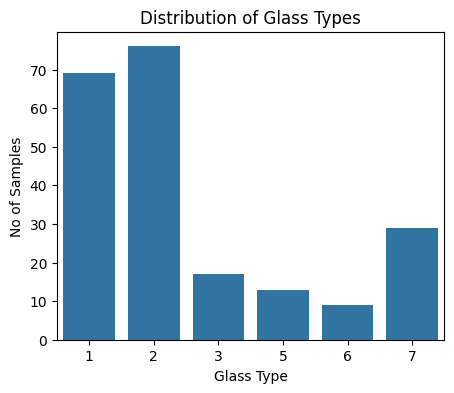

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Type')
plt.title("Distribution of Glass Types")
plt.xlabel("Glass Type")
plt.ylabel("No of Samples")
plt.show()

The target variable is not equally distributed across all glass types. Type 1 and Type 2 have the highest number of observations, while Type 6 has only 9 observations. Because some classes have much fewer samples than others, the dataset is considered imbalanced. This is important because a model could perform well on the larger classes but struggle to correctly identify the smaller classes.

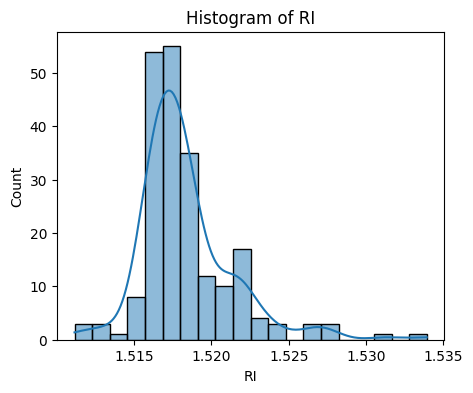

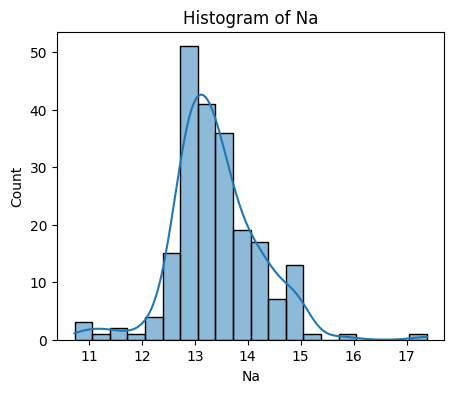

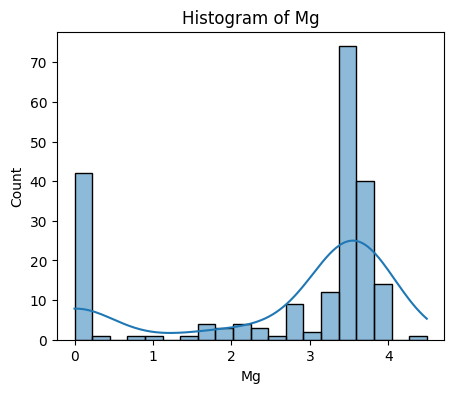

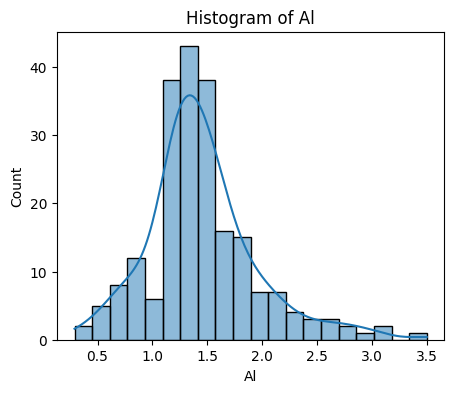

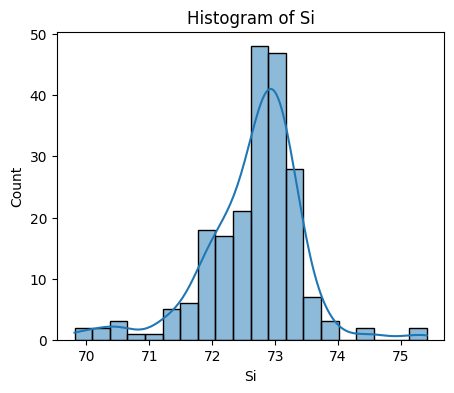

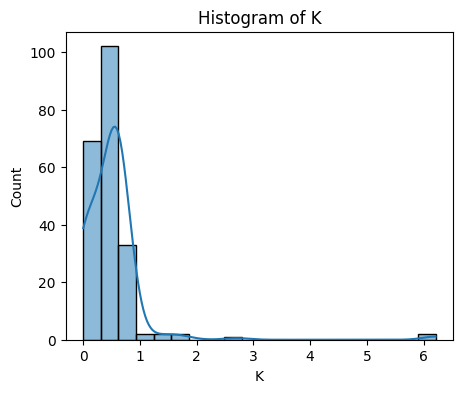

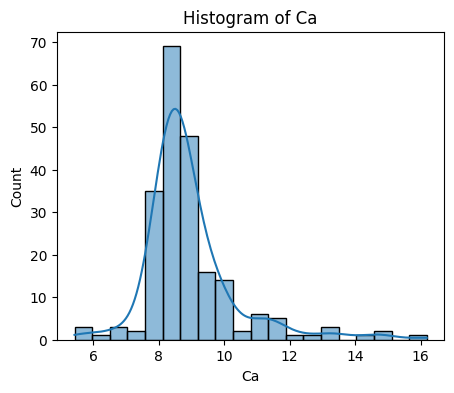

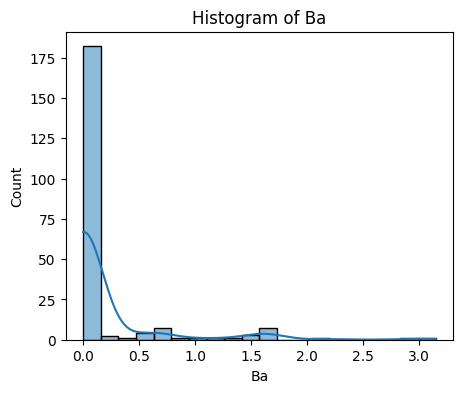

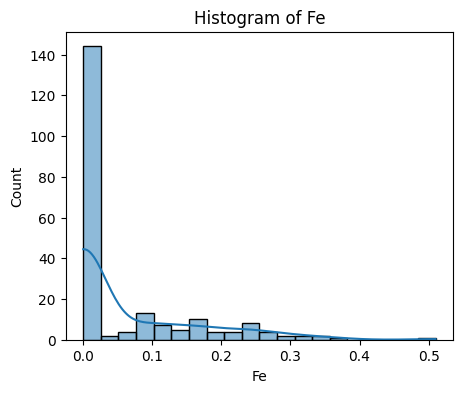

In [13]:
colu = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
for col in colu:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

The histograms help us understand how the values of each glass feature are distributed. We can see that the features have different ranges and shapes. For example, RI and Si are concentrated within a narrow range, while K, Ba and Fe have more values close to zero with a few higher values. This gives us an idea about the spread of the chemical properties before building the model.

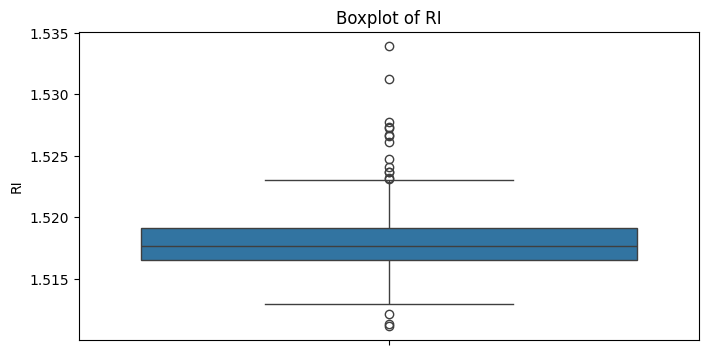

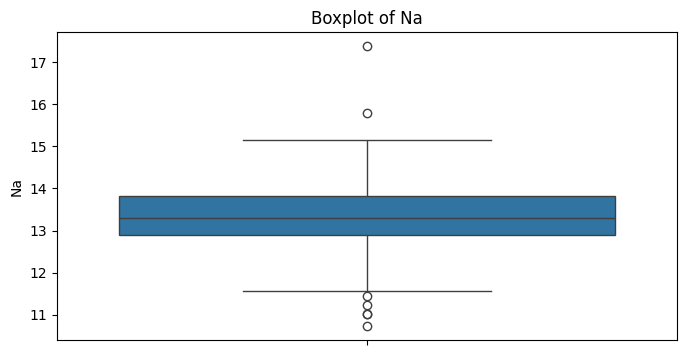

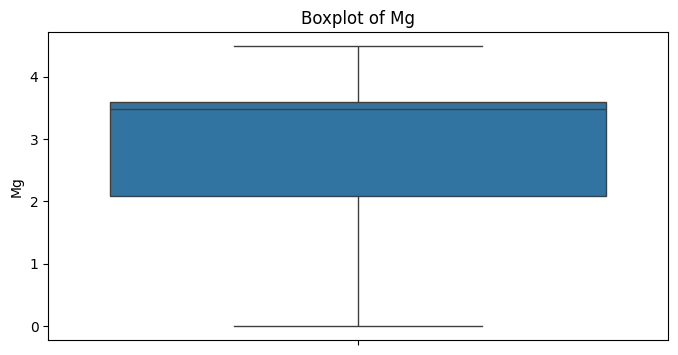

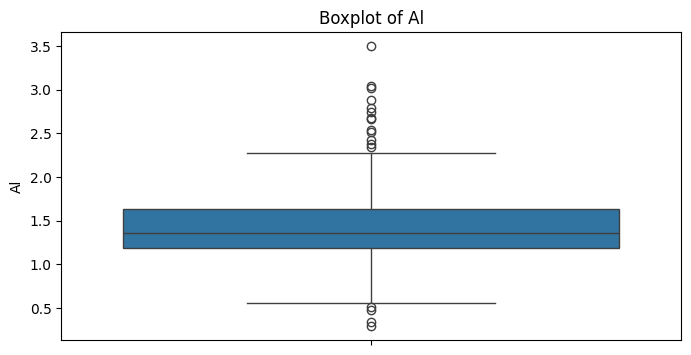

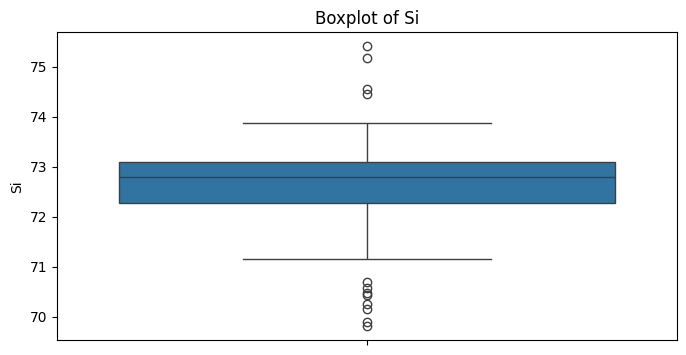

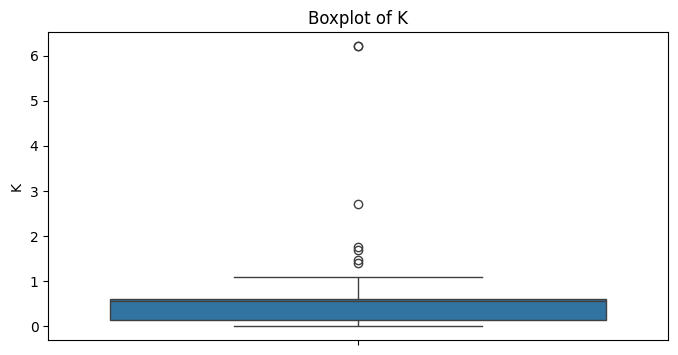

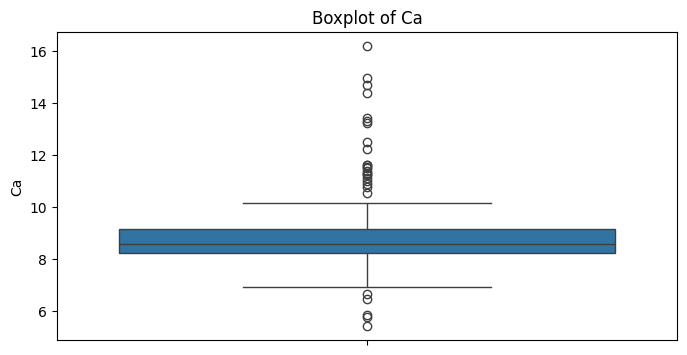

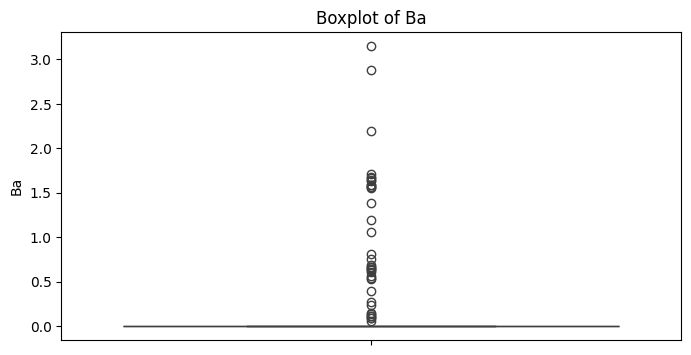

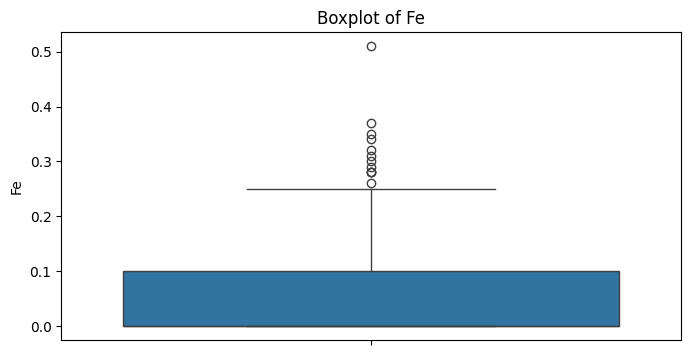

In [14]:
for col in colu:
    plt.figure(figsize=(8,4))
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show

The box plots help us identify unusual or extreme values in the features. Some features such as RI, Ca, Ba and K show potential outliers. However, these values were not removed because they may represent genuine differences in the chemical composition of different types of glass rather than errors in the data.

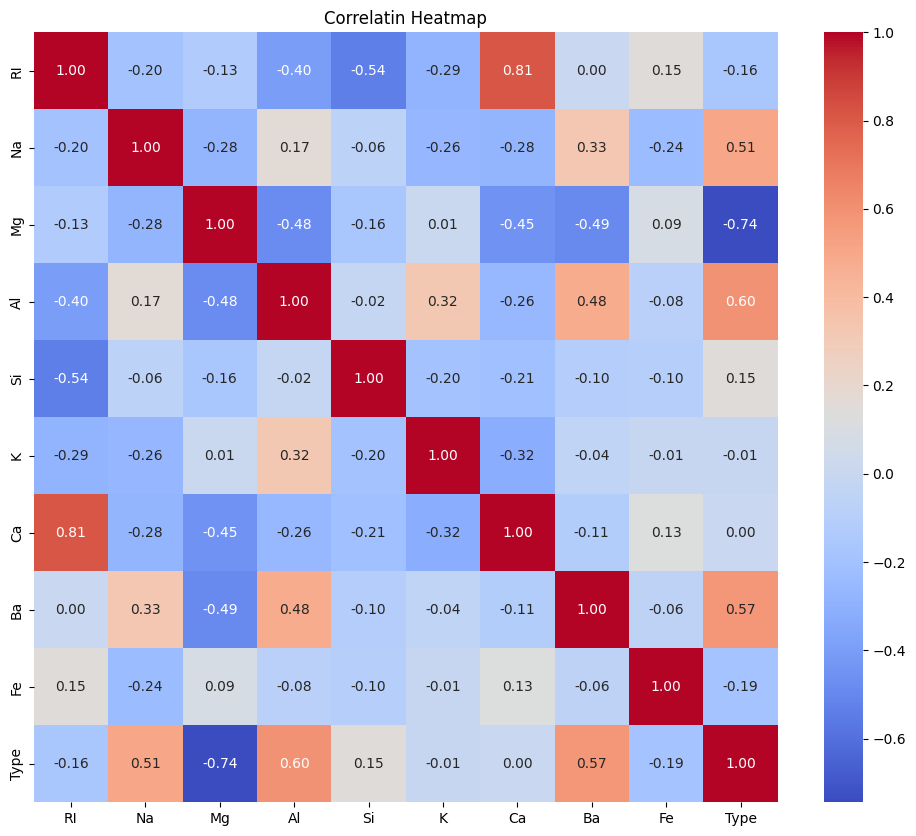

In [15]:
plt.figure(figsize=(12,10))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap = 'coolwarm',
    fmt='.2f'
)
plt.title('Correlatin Heatmap')
plt.show()

The correlation heatmap shows how strongly the features are related to each other and to the target variable, Type. Mg has the strongest negative correlation with Type at -0.745, while Al has a positive correlation of 0.599. Na and Ba also have moderate positive correlations with Type. This suggests that these features may provide useful information for distinguishing between different glass types.

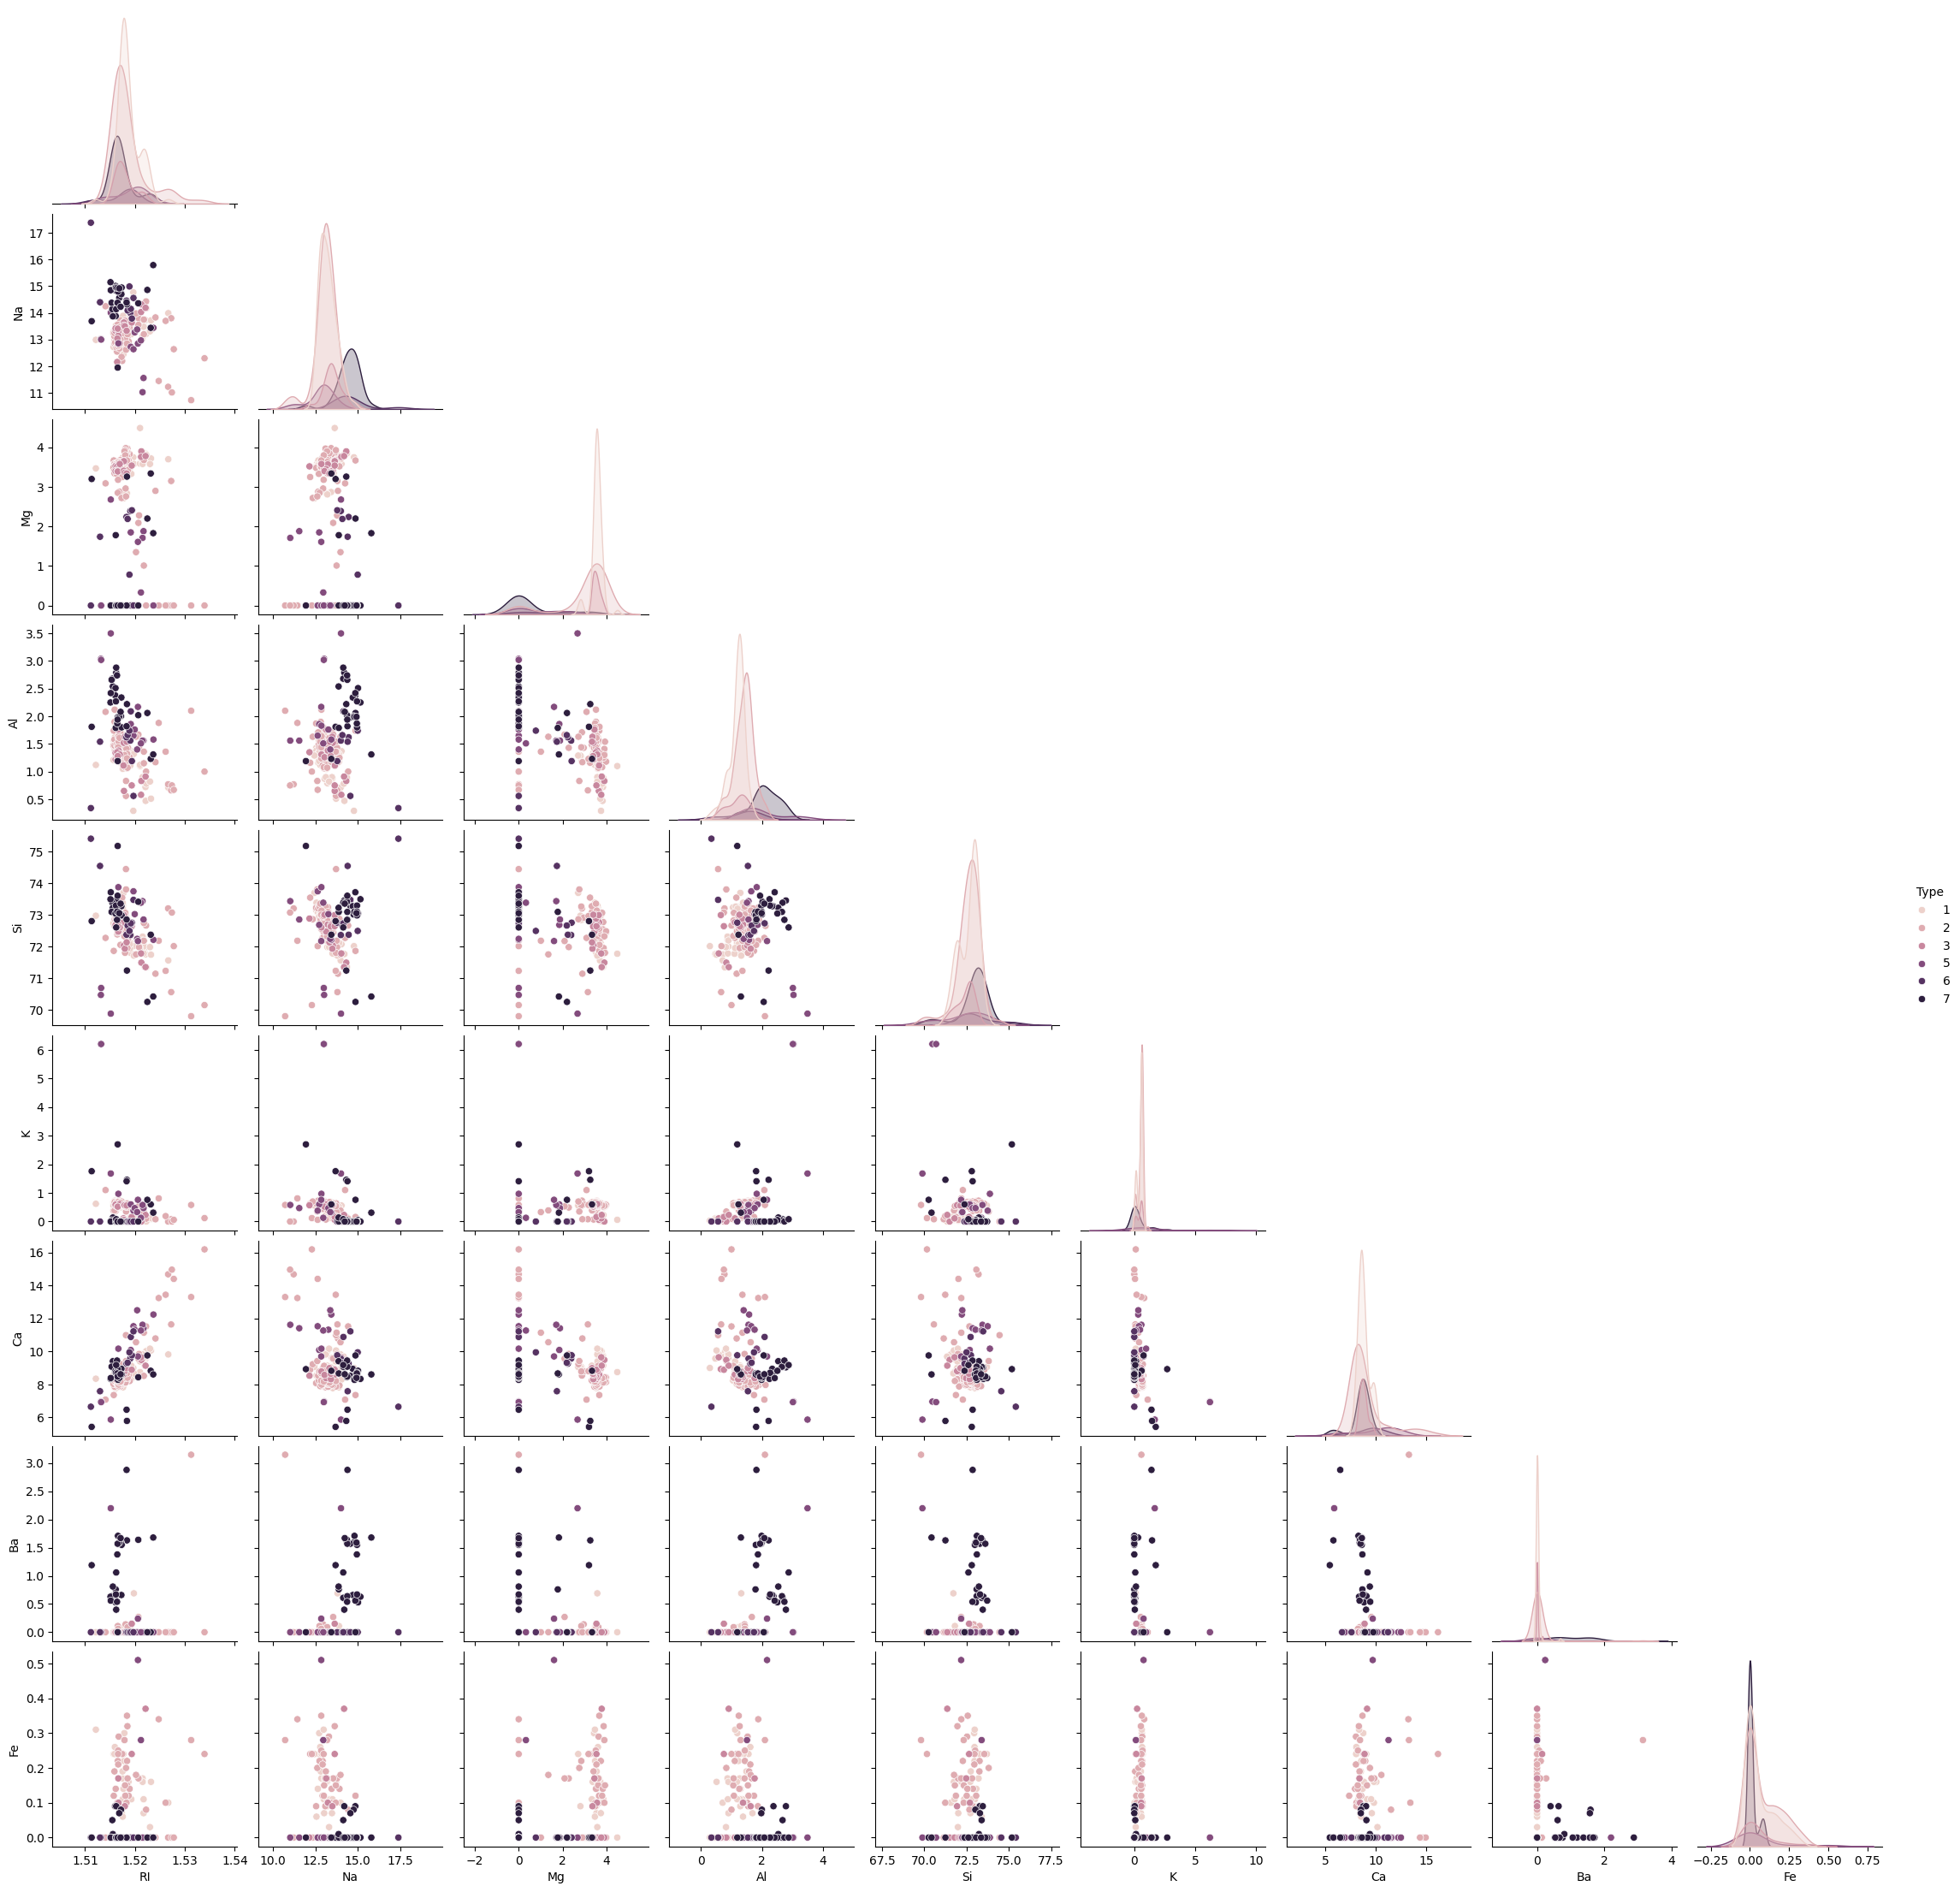

In [16]:
sns.pairplot(
    df,
    hue="Type",
    corner=True
)
plt.show()

In [17]:
X= df.drop(columns='Type')
y = df['Type']

In [18]:
X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


In [19]:
print(X.dtypes)

RI    float64
Na    float64
Mg    float64
Al    float64
Si    float64
K     float64
Ca    float64
Ba    float64
Fe    float64
dtype: object


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, train_size=0.8, random_state=42, stratify=y)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((170, 9), (43, 9), (170,), (43,))

In [23]:
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=1
    ))
])

Random Forest is an ensemble machine learning algorithm that creates many decision trees and combines their predictions. Instead of depending on one tree, it uses multiple trees, which generally makes the prediction more stable and reduces the chance of overfitting. Since the dataset is imbalanced, class weighting is used to give more importance to the minority classes.

In [24]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [25]:
y_pred = rf_model.predict(X_test)

The trained Random Forest uses the chemical properties of each test sample to predict its glass type. These predictions are then compared with the actual glass types to evaluate how well the model performed.

In [26]:
accuracy_rf = accuracy_score(y_test,y_pred)
print("Accuracy :", accuracy_rf)

Accuracy : 0.7906976744186046


The Random Forest achieved an accuracy of approximately 79.07%. This means that the model correctly classified about 79 out of every 100 test observations. Accuracy gives us an overall idea of how many predictions were correct, but because our dataset is imbalanced, we should also look at precision, recall and F1-score.

In [27]:
precision_rf = precision_score(y_test,y_pred,average='weighted',zero_division=0)
print('Precision', precision_rf)

Precision 0.8100775193798448


Precision tells us how reliable the model's positive predictions are. A precision of 81.01% means that when the model predicts a particular glass class, the prediction is correct about 81% of the time on average using the weighted calculation.

In [28]:
recall_rf = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
print("Recall:", recall_rf)

Recall: 0.7906976744186046


Recall measures how many of the actual glass samples were correctly identified by the model. A recall of 79.07% means that the model was able to correctly identify about 79% of the actual samples overall using the weighted calculation.

In [29]:
f1_rf = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
print("F1 Score:", f1_rf)

F1 Score: 0.7919661733615222


F1-score combines precision and recall into a single measure. It is useful when the dataset is imbalanced because it considers both the correctness of predictions and the ability to identify actual samples. A score of 79.20% indicates that the model has a reasonably good balance between precision and recall.

In [30]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.73      0.73      0.73        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.79        43
   macro avg       0.86      0.79      0.81        43
weighted avg       0.81      0.79      0.79        43



The classification report provides precision, recall and F1-score separately for each glass type. This is important because the overall accuracy can hide poor performance on minority classes. By looking at each class individually, we can identify which glass types are easier or harder for the model to classify.

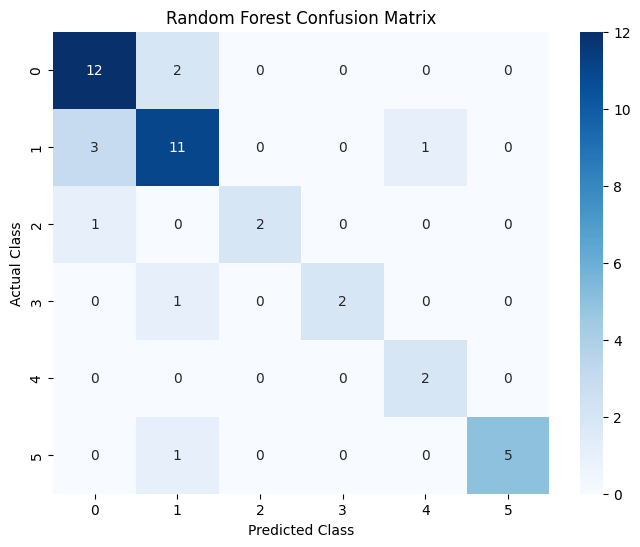

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

The confusion matrix gives a detailed view of the model's correct and incorrect predictions. The values along the diagonal represent correctly classified samples, while the values outside the diagonal represent misclassifications. It helps us understand which glass types the model is confusing with each other.

In [32]:
rf = rf_model.named_steps["rf"]
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(importance)

Mg    0.170191
Ca    0.141457
Na    0.134147
K     0.131605
Al    0.122035
RI    0.110630
Si    0.084206
Ba    0.082361
Fe    0.023368
dtype: float64


In [33]:
rf = rf_model.named_steps["rf"]
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(importance)

Mg    0.170191
Ca    0.141457
Na    0.134147
K     0.131605
Al    0.122035
RI    0.110630
Si    0.084206
Ba    0.082361
Fe    0.023368
dtype: float64


Feature importance shows which chemical properties contributed more to the Random Forest's decisions. A feature with higher importance had a greater role in separating the different glass types. This helps us understand not only how well the model performs, but also which variables are useful for classification.

In [34]:
bagging_model = Pipeline([
    ("scaler", StandardScaler()),
    ("bagging", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

Bagging creates multiple decision-tree models using different samples of the training data and combines their predictions. The main purpose is to make the overall model more stable and reduce the effect of an individual tree making a poor prediction.

In [35]:
bagging_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('bagging', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",300
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0


In [36]:
y_pred_bagging = bagging_model.predict(X_test)

In [37]:
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(
    y_test,
    y_pred_bagging,
    average="weighted",
    zero_division=0
)
bagging_recall = recall_score(
    y_test,
    y_pred_bagging,
    average="weighted",
    zero_division=0
)
bagging_f1 = f1_score(
    y_test,
    y_pred_bagging,
    average="weighted",
    zero_division=0
)
print("Accuracy:", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall:", bagging_recall)
print("F1 Score:", bagging_f1)

Accuracy: 0.7906976744186046
Precision: 0.8031007751937984
Recall: 0.7906976744186046
F1 Score: 0.7916454035138878


The Bagging model achieved around 79% accuracy, meaning it correctly classified most of the test samples. Its performance is very close to Random Forest in this experiment. This shows that using multiple decision trees improves stability, but the additional random feature selection used by Random Forest did not produce a large difference on this particular test split.

In [38]:
boosting_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

Boosting works differently from Bagging. Instead of building independent trees, it builds models sequentially. Each new model tries to improve the mistakes made by the previous models. In this way, several weaker models are combined to create a stronger model.

In [39]:
boosting_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [40]:
y_pred_boosting = boosting_model.predict(X_test)

In [41]:
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)

boosting_precision = precision_score(
    y_test,
    y_pred_boosting,
    average="weighted",
    zero_division=0
)

boosting_recall = recall_score(
    y_test,
    y_pred_boosting,
    average="weighted",
    zero_division=0
)

boosting_f1 = f1_score(
    y_test,
    y_pred_boosting,
    average="weighted",
    zero_division=0
)

print("Accuracy:", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall:", boosting_recall)
print("F1 Score:", boosting_f1)

Accuracy: 0.8372093023255814
Precision: 0.84718910820142
Recall: 0.8372093023255814
F1 Score: 0.8317084078711986


Gradient Boosting achieved the best overall performance among the three models on this test split. Its accuracy of 83.72% means that it correctly classified around 84 out of every 100 test samples. The precision of 84.72% shows that its predictions were relatively reliable, while the recall of 83.72% indicates that it successfully identified most of the actual classes. The F1-score of 83.17% shows a good balance between precision and recall.

In [42]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_rf,
        bagging_accuracy,
        boosting_accuracy
    ],

    "Precision": [
        precision_rf,
        bagging_precision,
        boosting_precision
    ],

    "Recall": [
        recall_rf,
        bagging_recall,
        boosting_recall
    ],

    "F1 Score": [
        f1_rf,
        bagging_f1,
        boosting_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.790698,0.810078,0.790698,0.791966
1,Bagging,0.790698,0.803101,0.790698,0.791645
2,Gradient Boosting,0.837209,0.847189,0.837209,0.831708


Based on the results, Gradient Boosting performed the best on the selected test data, with an accuracy of 83.72% and an F1-score of 83.17%. Random Forest and Bagging produced very similar results, both achieving around 79% accuracy. The better performance of Gradient Boosting suggests that its sequential learning approach was more effective at capturing the patterns in this dataset. However, the Glass dataset is relatively small, so the scores may change if a different train-test split is used.

Additional Notes
#### 1. Bagging and Boosting
- Bagging (Bootstrap Aggregating) is an ensemble technique where multiple models, usually decision trees, are trained independently on different random samples of the training data. Their predictions are then combined, usually by majority voting for classification.

- Boosting is also an ensemble technique, but the models are built one after another. Each new model focuses more on the mistakes made by the previous models. The models are then combined to produce a stronger final prediction.

- Bagging builds multiple models independently using different samples of the data and combines their predictions to get a more stable result. Boosting, on the other hand, builds models one after another, where each new model tries to improve the mistakes made by the previous one. In simple terms, Bagging focuses on combining many independent models, while Boosting focuses on learning from previous mistakes.

#### 2. Handling Imbalance in Data
Imbalanced data means that some classes have many more samples than others. In our Glass dataset, some glass types have fewer observations, so the model may favor the majority classes. To handle this, we can use techniques like class weighting, oversampling, or undersampling. We can also use precision, recall, and F1-score along with accuracy to make sure the minority classes are being predicted properly.
